In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

print("✅ Все библиотеки загружены")
print("✅ Готовы к анализу")

✅ Все библиотеки загружены
✅ Готовы к анализу


In [2]:
import os

# Проверяем файлы из Article 5
data_path = "heatwave_data"
print("📁 Файлы в heatwave_data:")
if os.path.exists(data_path):
    for f in os.listdir(data_path):
        size_mb = os.path.getsize(os.path.join(data_path, f)) / (1024*1024)
        print(f" — {f} ({size_mb:.1f} MB)")
else:
    print("❌ Папка не найдена")

print()
print("📁 Все файлы в текущей папке:")
for f in os.listdir("."):
    print(f" — {f}")


📁 Файлы в heatwave_data:
 — HWD_EU_health_rcp45_mean_v1.0.nc (97.1 MB)
 — HWD_EU_health_rcp85_mean_v1.0.nc (97.1 MB)

📁 Все файлы в текущей папке:
 — .android
 — .bash_history
 — .cdsapirc
 — .gitconfig
 — .gradle
 — .idlerc
 — .ipynb_checkpoints
 — .ipython
 — .jupyter
 — .local
 — .matplotlib
 — .Protege
 — .python_history
 — .vscode
 — .vscode-shared
 — 3D Objects
 — AndroidStudioProjects
 — AppData
 — Application Data
 — climate_env
 — Contacts
 — Cookies
 — Desktop
 — Documents
 — Downloads
 — Dropbox
 — eu_climate_risk_dashboard.ipynb
 — Favorites
 — flutter_application_1
 — Google Drive
 — heatwave_analysis
 — heatwave_by_country.png
 — heatwave_data
 — heatwave_days_analysis.ipynb
 — heatwave_days_europe.zip
 — heatwave_map_europe.png
 — heatwave_timeseries_europe.png
 — IntelGraphicsProfiles
 — Links
 — Local Settings
 — Microsoft
 — MicrosoftEdgeBackups
 — Music
 — My Documents
 — NetHood
 — NTUSER.DAT
 — ntuser.dat.LOG1
 — ntuser.dat.LOG2
 — NTUSER.DAT{2ad838bc-efea-11ee-a54

In [3]:
import cdsapi
import os

os.makedirs("climate_risk_data", exist_ok=True)

c = cdsapi.Client()

# Drought — consecutive dry days из агроклиматических индикаторов
print("⏳ Скачиваем данные по засухе...")
c.retrieve(
    'sis-agroclimatic-indicators',
    {
        'variable': 'consecutive_dry_days',
        'period': 'future',
        'experiment': 'rcp8_5',
        'ensemble_statistic': 'ensemble_mean',
        'horizon': '2041_2060',
    },
    'climate_risk_data/drought_cdd_europe.zip'
)
print("✅ Данные по засухе скачаны!")


⏳ Скачиваем данные по засухе...


HTTPError: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/sis-agroclimatic-indicators/execution
invalid request
Request has not produced a valid combination of values, please check your selection.
{'ensemble_statistic': 'ensemble_mean', 'experiment': 'rcp8_5', 'horizon': '2041_2060', 'period': 'future', 'variable': 'consecutive_dry_days'}

In [4]:
import cdsapi
import os

os.makedirs("climate_risk_data", exist_ok=True)

dataset = "sis-agroclimatic-indicators"
request = {
    "origin": "hadgem2_es_model",
    "variable": ["maximum_number_of_consecutive_dry_days"],
    "experiment": "rcp8_5",
    "temporal_aggregation": "season",
    "period": [
        "201101_204012",
        "204101_207012",
        "207101_209912"
    ],
    "version": ["1_0"]
}

client = cdsapi.Client()
print("⏳ Скачиваем данные по засухе...")
client.retrieve(dataset, request).download("climate_risk_data/drought_cdd_europe.zip")
print("✅ Данные по засухе скачаны!")


⏳ Скачиваем данные по засухе...


2026-09-10 13:35:49,137 INFO Request ID is add64fc7-5e34-467d-8fdd-54eaff7fbb3b
2026-09-10 13:35:49,268 INFO status has been updated to accepted
2026-09-10 13:36:04,753 INFO status has been updated to successful


5fabf9f16b4a26a8cda94a8b0107054d.zip:   0%|          | 0.00/19.5M [00:00<?, ?B/s]

✅ Данные по засухе скачаны!


In [6]:
import zipfile
import os

# Разархивируем данные по засухе
with zipfile.ZipFile("climate_risk_data/drought_cdd_europe.zip", "r") as zip_ref:
    zip_ref.extractall("climate_risk_data/drought")

print("📁 Файлы по засухе:")
for f in os.listdir("climate_risk_data/drought"):
    size_mb = os.path.getsize(os.path.join("climate_risk_data/drought", f)) / (1024*1024)
    print(f" — {f} ({size_mb:.1f} MB)")

📁 Файлы по засухе:
 — CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20110101-20401231_v1.0.nc (6.6 MB)
 — CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc (6.6 MB)
 — CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20710101-20991231_v1.0.nc (6.3 MB)


In [7]:
import xarray as xr

# Открываем средний период 2041-2070
drought = xr.open_dataset("climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc")
print("📊 Структура drought данных:")
print(drought)
print()
print("📅 Переменные:", list(drought.data_vars))
print("📍 Координаты:", list(drought.coords))

📊 Структура drought данных:
<xarray.Dataset> Size: 123MB
Dimensions:      (time: 119, bounds: 2, lat: 360, lon: 720)
Coordinates:
  * time         (time) datetime64[ns] 952B 2041-04-16 2041-07-16 ... 2070-10-16
  * lat          (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon          (lon) float64 6kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
Dimensions without coordinates: bounds
Data variables:
    time_bounds  (time, bounds) datetime64[ns] 2kB ...
    CDD          (time, lat, lon) float32 123MB ...
Attributes: (12/14)
    title:          CDD index from ECA drought indices
    institution:    Copernicus Climate Change Service
    source:         Climate projection datasets from the ISIMIP Fast Track pr...
    references:     Tank, A.K., 2010. European Climate Assessment and Dataset...
    comment:        
    history:        Tue Sep 19 09:55:31 2017: cdo -f nc4c -z zip mergetime pr...
    ...             ...
    contact:        https://climate.copernicus.eu
    

In [8]:
import cdsapi
import os

dataset = "sis-european-risk-extreme-precipitation-indicators"
request = {
    "spatial_coverage": ["europe"],
    "variable": ["number_of_consecutive_wet_days"],
    "product_type": ["era5"],
    "temporal_aggregation": ["yearly"],
    "period": [
        "2010", "2011", "2012", "2013", "2014",
        "2015", "2016", "2017", "2018", "2019"
    ]
}

client = cdsapi.Client()
print("⏳ Скачиваем данные по наводнениям...")
client.retrieve(dataset, request).download("climate_risk_data/flood_cwd_europe.zip")
print("✅ Данные по наводнениям скачаны!")

⏳ Скачиваем данные по наводнениям...


2026-09-10 13:50:12,985 INFO [2025-01-29T00:00:00] This dataset is no longer supported by the data providers. Data and documentation are provided as is. Users are encouraged to use our [Forum](https://forum.ecmwf.int/) to raise any item of discussion with respect to this dataset.
2026-09-10 13:50:12,986 INFO Request ID is 02bf5a70-a3b6-4601-b57d-e1dcd5955668
2026-09-10 13:50:13,252 INFO status has been updated to accepted
2026-09-10 13:50:34,590 INFO status has been updated to successful


20948140abb36c2b2fc332872df54f6e.zip:   0%|          | 0.00/3.01M [00:00<?, ?B/s]

✅ Данные по наводнениям скачаны!


In [9]:
import zipfile
import os

# Разархивируем flood данные
with zipfile.ZipFile("climate_risk_data/flood_cwd_europe.zip", "r") as zip_ref:
    zip_ref.extractall("climate_risk_data/flood")

print("📁 Файлы по наводнениям:")
for f in os.listdir("climate_risk_data/flood"):
    size_mb = os.path.getsize(os.path.join("climate_risk_data/flood", f)) / (1024*1024)
    print(f" — {f} ({size_mb:.1f} MB)")

📁 Файлы по наводнениям:
 — number-of-consecutive-wet-days_europe_era5_yearly_2010_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2011_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2012_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2013_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2014_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2015_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2016_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2017_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2018_v1.nc (0.3 MB)
 — number-of-consecutive-wet-days_europe_era5_yearly_2019_v1.nc (0.3 MB)


In [10]:
import xarray as xr

# Открываем один файл для проверки
flood = xr.open_dataset("climate_risk_data/flood/number-of-consecutive-wet-days_europe_era5_yearly_2019_v1.nc")
print("📊 Структура flood данных:")
print(flood)
print()
print("📅 Переменные:", list(flood.data_vars))
print("📍 Координаты:", list(flood.coords))


📊 Структура flood данных:
<xarray.Dataset> Size: 305kB
Dimensions:    (time: 1, latitude: 145, longitude: 261)
Coordinates:
  * time       (time) datetime64[ns] 8B 2019-12-31
  * latitude   (latitude) float32 580B 71.0 70.75 70.5 70.25 ... 35.5 35.25 35.0
  * longitude  (longitude) float64 2kB -25.0 -24.75 -24.5 ... 39.5 39.75 40.0
Data variables:
    cwd        (time, latitude, longitude) float64 303kB ...
Attributes:
    Conventions:  CF-1.6
    contacts:     copernicus-support@ecmwf.int
    contract:     C3S_430 Sectoral Information System to support Disaster Ris...
    title:        Extreme precipitation indicators for Europe and European ci...
    institution:  Fondazione Centro Euro-Mediterraneo sui Cambiamenti Climati...
    author:       Fondazione Centro Euro-Mediterraneo sui Cambiamenti Climati...
    version:      version 1.0

📅 Переменные: ['cwd']
📍 Координаты: ['time', 'longitude', 'latitude']


In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

# ── ЗАГРУЖАЕМ ВСЕ ТРИ ДАТАСЕТА ──

# 1. Heatwave — RCP 8.5, 2085
rcp85 = xr.open_dataset("heatwave_data/HWD_EU_health_rcp85_mean_v1.0.nc")
heatwave = rcp85.HWD_EU_health.isel(time=99)  # 2085

# 2. Drought — CDD, период 2041-2070, летний сезон (JJA)
drought_ds = xr.open_dataset("climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc")
# Выбираем летний сезон (июль) и усредняем по всему периоду
drought_summer = drought_ds.CDD.sel(
    time=drought_ds.time.dt.month == 7,
    lat=slice(35, 72),
    lon=slice(-25, 40)
).mean(dim='time')

# 3. Flood — среднее за 2010-2019
flood_files = sorted(glob.glob("climate_risk_data/flood/*.nc"))
flood_datasets = [xr.open_dataset(f).cwd.isel(time=0) for f in flood_files]
flood_mean = xr.concat(flood_datasets, dim='year').mean(dim='year')

print("✅ Все данные загружены!")
print(f"Heatwave: {heatwave.shape}")
print(f"Drought:  {drought_summer.shape}")
print(f"Flood:    {flood_mean.shape}")

✅ Все данные загружены!
Heatwave: (425, 599)
Drought:  (74, 130)
Flood:    (145, 261)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

europe_extent = [-25, 40, 35, 72]

# ── КАРТА 1: HEATWAVE RISK ──
ax1 = axes[0]
im1 = ax1.pcolormesh(rcp85.lon, rcp85.lat, heatwave,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrRd', vmin=0, vmax=80)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax1.set_title('Heatwave Risk\nDays per

SyntaxError: unterminated string literal (detected at line 16) (4075182808.py, line 16)

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


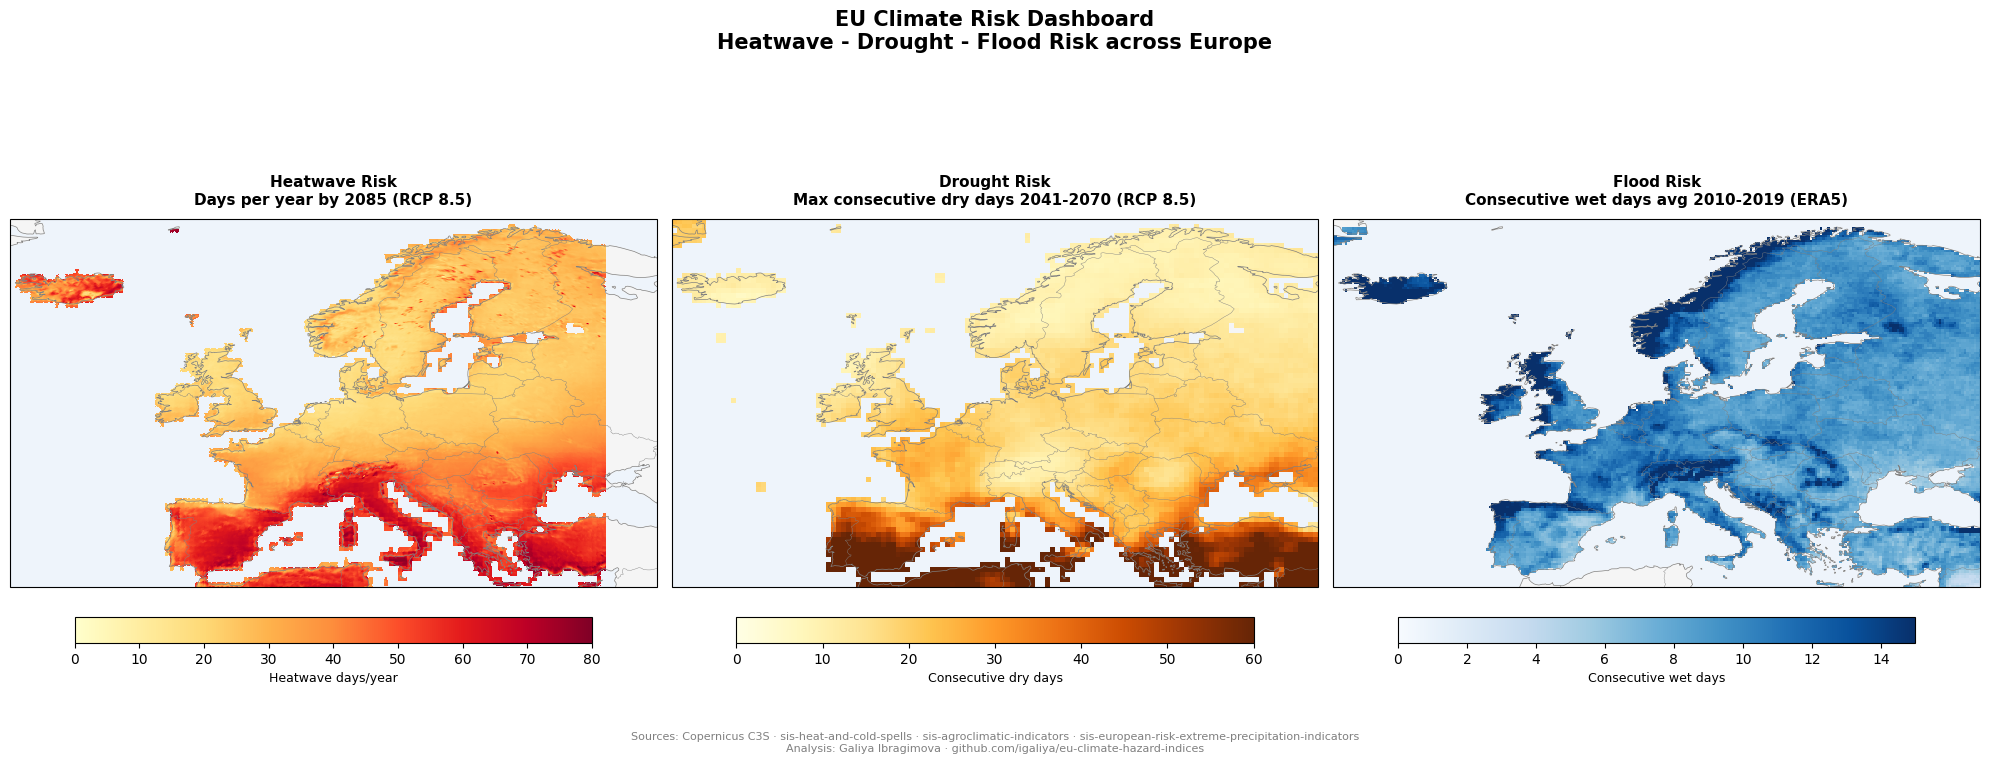

✅ Дашборд сохранён!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

europe_extent = [-25, 40, 35, 72]

# ── КАРТА 1: HEATWAVE RISK ──
ax1 = axes[0]
im1 = ax1.pcolormesh(rcp85.lon, rcp85.lat, heatwave,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrRd', vmin=0, vmax=80)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(europe_extent, crs=ccrs.PlateCarree())
title1 = 'Heatwave Risk\nDays per year by 2085 (RCP 8.5)'
ax1.set_title(title1, fontsize=11, fontweight='bold', pad=10)
cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
cbar1.set_label('Heatwave days/year', fontsize=9)

# ── КАРТА 2: DROUGHT RISK ──
ax2 = axes[1]
im2 = ax2.pcolormesh(drought_summer.lon, drought_summer.lat, drought_summer,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrBr', vmin=0, vmax=60)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(europe_extent, crs=ccrs.PlateCarree())
title2 = 'Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)'
ax2.set_title(title2, fontsize=11, fontweight='bold', pad=10)
cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('Consecutive dry days', fontsize=9)

# ── КАРТА 3: FLOOD RISK ──
ax3 = axes[2]
im3 = ax3.pcolormesh(flood_mean.longitude, flood_mean.latitude, flood_mean,
                      transform=ccrs.PlateCarree(),
                      cmap='Blues', vmin=0, vmax=15)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax3.set_extent(europe_extent, crs=ccrs.PlateCarree())
title3 = 'Flood Risk\nConsecutive wet days avg 2010-2019 (ERA5)'
ax3.set_title(title3, fontsize=11, fontweight='bold', pad=10)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
cbar3.set_label('Consecutive wet days', fontsize=9)

# ── ЗАГОЛОВОК И ИСТОЧНИКИ ──
main_title = 'EU Climate Risk Dashboard\nHeatwave - Drought - Flood Risk across Europe'
fig.suptitle(main_title, fontsize=15, fontweight='bold', y=1.02)

source_text = ('Sources: Copernicus C3S · sis-heat-and-cold-spells · '
               'sis-agroclimatic-indicators · sis-european-risk-extreme-precipitation-indicators\n'
               'Analysis: Galiya Ibragimova · github.com/igaliya/eu-climate-hazard-indices')
fig.text(0.5, -0.04, source_text, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('eu_climate_risk_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Дашборд сохранён!")

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Заменяем NaN на маску
drought_masked = np.ma.masked_invalid(drought_summer.values)
flood_masked = np.ma.masked_invalid(flood_mean.values)

print(f"Drought — мин: {np.nanmin(drought_summer.values):.1f}, макс: {np.nanmax(drought_summer.values):.1f}")
print(f"Flood — мин: {np.nanmin(flood_mean.values):.1f}, макс: {np.nanmax(flood_mean.values):.1f}")
print(f"Heatwave — мин: {float(heatwave.min()):.1f}, макс: {float(heatwave.max()):.1f}")

Drought — мин: 5.9, макс: 92.0
Flood — мин: 2.6, макс: 31.4
Heatwave — мин: 9.8, макс: 83.2


In [15]:
import numpy as np

print(f"Drought — мин: {np.nanmin(drought_summer.values):.1f}, макс: {np.nanmax(drought_summer.values):.1f}")
print(f"Flood — мин: {np.nanmin(flood_mean.values):.1f}, макс: {np.nanmax(flood_mean.values):.1f}")
print(f"Heatwave — мин: {float(heatwave.min()):.1f}, макс: {float(heatwave.max()):.1f}")

Drought — мин: 5.9, макс: 92.0
Flood — мин: 2.6, макс: 31.4
Heatwave — мин: 9.8, макс: 83.2


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


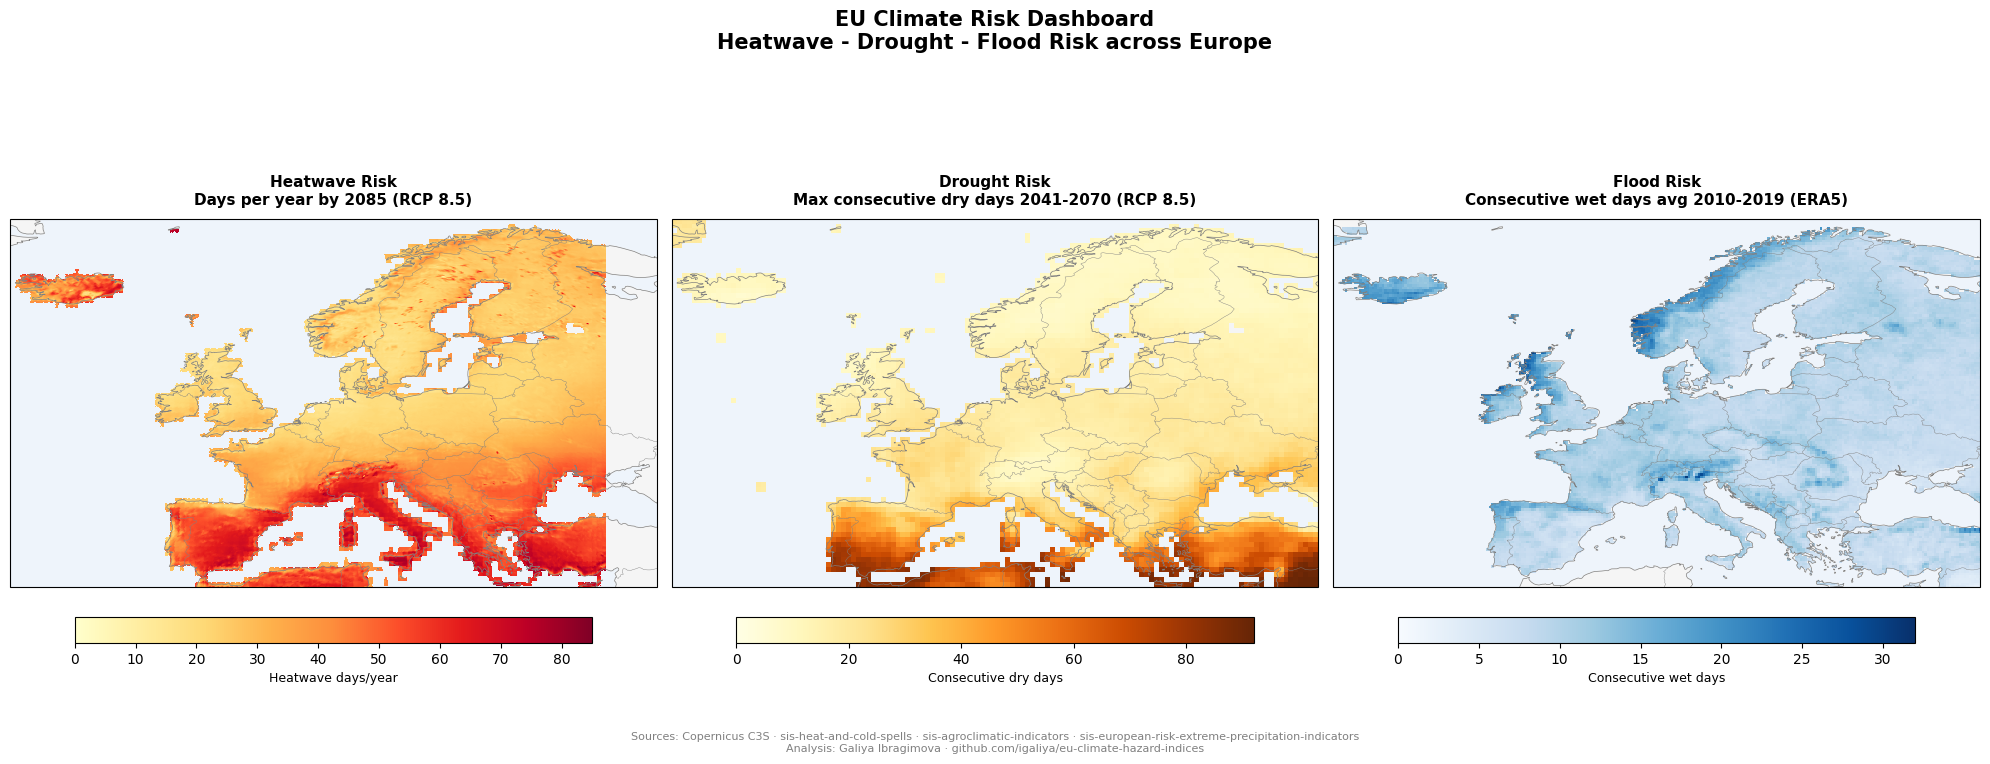

✅ Дашборд обновлён!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

europe_extent = [-25, 40, 35, 72]

# ── КАРТА 1: HEATWAVE ──
ax1 = axes[0]
im1 = ax1.pcolormesh(rcp85.lon, rcp85.lat, heatwave,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrRd', vmin=0, vmax=85)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax1.set_title('Heatwave Risk\nDays per year by 2085 (RCP 8.5)',
              fontsize=11, fontweight='bold', pad=10)
cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
cbar1.set_label('Heatwave days/year', fontsize=9)

# ── КАРТА 2: DROUGHT ──
ax2 = axes[1]
im2 = ax2.pcolormesh(drought_summer.lon, drought_summer.lat, drought_summer,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrBr', vmin=0, vmax=92)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)',
              fontsize=11, fontweight='bold', pad=10)
cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('Consecutive dry days', fontsize=9)

# ── КАРТА 3: FLOOD ──
ax3 = axes[2]
im3 = ax3.pcolormesh(flood_mean.longitude, flood_mean.latitude, flood_mean,
                      transform=ccrs.PlateCarree(),
                      cmap='Blues', vmin=0, vmax=32)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax3.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax3.set_title('Flood Risk\nConsecutive wet days avg 2010-2019 (ERA5)',
              fontsize=11, fontweight='bold', pad=10)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
cbar3.set_label('Consecutive wet days', fontsize=9)

# ── ЗАГОЛОВОК И ИСТОЧНИКИ ──
main_title = 'EU Climate Risk Dashboard\nHeatwave - Drought - Flood Risk across Europe'
fig.suptitle(main_title, fontsize=15, fontweight='bold', y=1.02)

source_text = ('Sources: Copernicus C3S · sis-heat-and-cold-spells · '
               'sis-agroclimatic-indicators · sis-european-risk-extreme-precipitation-indicators\n'
               'Analysis: Galiya Ibragimova · github.com/igaliya/eu-climate-hazard-indices')
fig.text(0.5, -0.04, source_text, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('eu_climate_risk_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Дашборд обновлён!")

In [17]:
print("✅ Дашборд готов к публикации!")
print(f"Файл сохранён: eu_climate_risk_dashboard.png")

import os
size_mb = os.path.getsize('eu_climate_risk_dashboard.png') / (1024*1024)
print(f"Размер файла: {size_mb:.1f} MB")

✅ Дашборд готов к публикации!
Файл сохранён: eu_climate_risk_dashboard.png
Размер файла: 0.7 MB


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


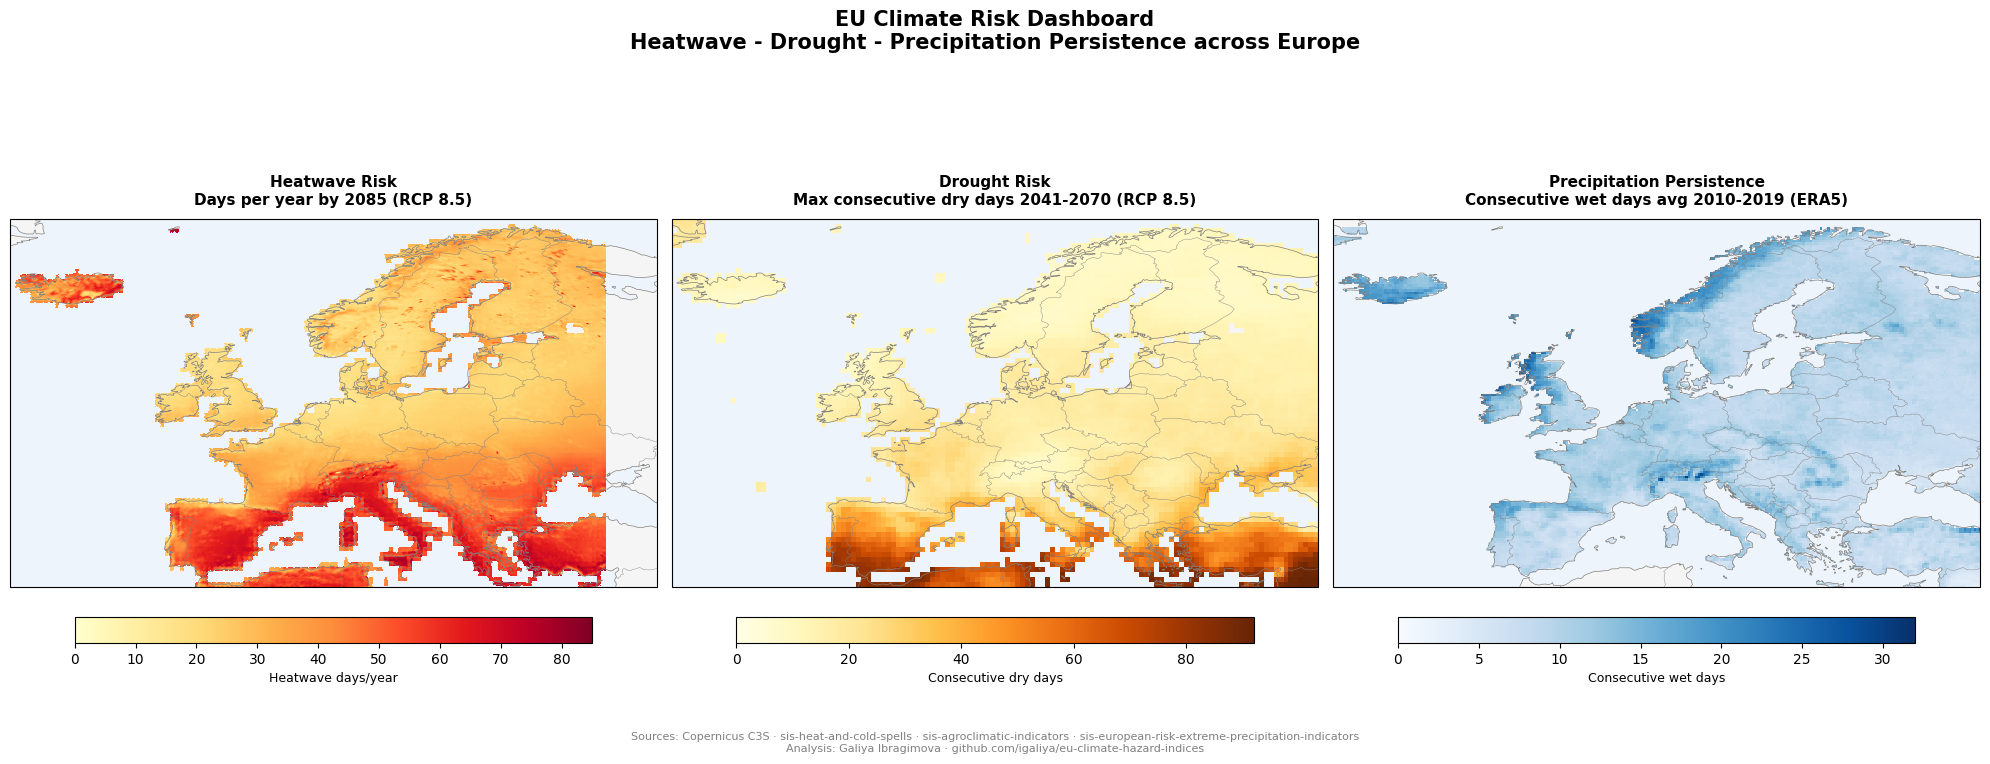

✅ Дашборд обновлён!


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

europe_extent = [-25, 40, 35, 72]

# ── КАРТА 1: HEATWAVE ──
ax1 = axes[0]
im1 = ax1.pcolormesh(rcp85.lon, rcp85.lat, heatwave,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrRd', vmin=0, vmax=85)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax1.set_title('Heatwave Risk\nDays per year by 2085 (RCP 8.5)',
              fontsize=11, fontweight='bold', pad=10)
cbar1 = plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
cbar1.set_label('Heatwave days/year', fontsize=9)

# ── КАРТА 2: DROUGHT ──
ax2 = axes[1]
im2 = ax2.pcolormesh(drought_summer.lon, drought_summer.lat, drought_summer,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrBr', vmin=0, vmax=92)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)',
              fontsize=11, fontweight='bold', pad=10)
cbar2 = plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('Consecutive dry days', fontsize=9)

# ── КАРТА 3: PRECIPITATION PERSISTENCE (обновлённое название) ──
ax3 = axes[2]
im3 = ax3.pcolormesh(flood_mean.longitude, flood_mean.latitude, flood_mean,
                      transform=ccrs.PlateCarree(),
                      cmap='Blues', vmin=0, vmax=32)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax3.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray')
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax3.set_extent(europe_extent, crs=ccrs.PlateCarree())
ax3.set_title('Precipitation Persistence\nConsecutive wet days avg 2010-2019 (ERA5)',
              fontsize=11, fontweight='bold', pad=10)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
cbar3.set_label('Consecutive wet days', fontsize=9)

# ── ЗАГОЛОВОК И ИСТОЧНИКИ ──
main_title = 'EU Climate Risk Dashboard\nHeatwave - Drought - Precipitation Persistence across Europe'
fig.suptitle(main_title, fontsize=15, fontweight='bold', y=1.02)

source_text = ('Sources: Copernicus C3S · sis-heat-and-cold-spells · '
               'sis-agroclimatic-indicators · sis-european-risk-extreme-precipitation-indicators\n'
               'Analysis: Galiya Ibragimova · github.com/igaliya/eu-climate-hazard-indices')
fig.text(0.5, -0.04, source_text, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('eu_climate_risk_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Дашборд обновлён!")